# Sequential Stop Detection (Sliding Window)

In [7]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles
import nomad.stop_detection.sequential as SEQUENTIAL
import nomad.stop_detection.lachesis as LACHESIS

import nomad.data as data_folder
from pathlib import Path

from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations

In [8]:
# Parameters according to the config file
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / "garden-city.gpkg")
buildings = gpd.read_parquet(data_dir / "garden-city-buildings-mercator.parquet")

In [9]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=6, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*6  # in minutes

location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2 + ['r-x20-y13'] * 1


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)
destinations = destinations[:-1]
destinations

,datetime,timestamp,duration,location
0,2024-06-01 00:00:00-08:00,1717228800,30,h-x14-y11
1,2024-06-01 00:30:00-08:00,1717230600,60,w-x17-y10
2,2024-06-01 01:30:00-08:00,1717234200,60,r-x19-y11


## Generate Synthetic Trajectory Data

In [10]:
# Create a synthetic agent trajectory
# Fixed: Agent() doesn't take 'name' parameter
Charlie = Agent(city=city, identifier='Charlie')
# Charlie.generate_trajectory(destination_diary=destinations,
#                             seed=19104,
#                             dt=0.2)

# Charlie.sample_trajectory(beta_start=None,
#                           beta_durations=None,
#                           beta_ping=7,
#                           seed=60,
#                           ha=11/15)

Charlie.generate_trajectory(destination_diary=destinations,
                            seed=2000,
                            dt=0.2)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=7,
                          seed=50,
                          ha=11/15)

traj = Charlie.sparse_traj

/Users/carolinechen/Desktop/cs/nomad/nomad/city_gen.py:1575: UserWarning: shortest_paths not initialized. Auto-initializing with callable_only=True. Call compute_shortest_paths() explicitly.
  warnings.warn("shortest_paths not initialized. Auto-initializing with callable_only=True. Call compute_shortest_paths() explicitly.", UserWarning)


## Test Sequential Stop Detection

In [11]:
# Parameters
delta_roam = 9 #city blocks
dt_max=120
dur_min=5

# Detect stops using sequential sliding window
sequential_stops = SEQUENTIAL.detect_stops(
    data=traj,
    delta_roam=delta_roam,
    dt_max=dt_max,
    dur_min=dur_min,
    method='sliding',
    complete_output=True,
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)

print(f"Detected {len(sequential_stops)} stops using sequential method")
print(f"\nFirst few stops:")
print(sequential_stops.head())

labels = SEQUENTIAL.detect_stop_labels(
    data=traj,
    delta_roam=delta_roam,
    dt_max=dt_max, 
    dur_min=dur_min,
    method='sliding',
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)
traj['cluster'] = labels

Detected 1 stops using sequential method

First few stops:
   cluster         x          y                  datetime        ha  diameter  \
0        0  18.22424  10.870702 2024-06-01 00:10:26-08:00  0.690751  7.258089   

   n_pings              end_datetime  duration  max_gap  user_id  
0       23 2024-06-01 02:21:38-08:00       131       17  Charlie  


## Visualize Results

/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'timestamp' specified for 'timestamp' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")


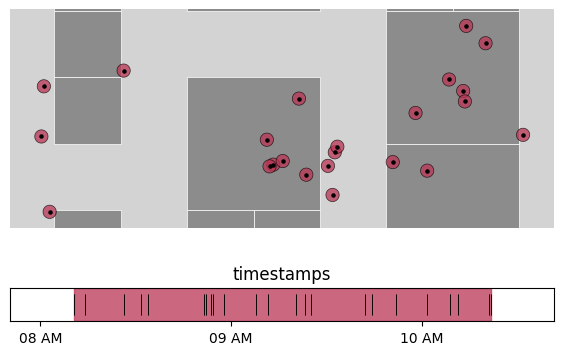

In [12]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.1, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(sequential_stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj['timestamp'], color='cluster', ax=ax_barcode, set_xlim=False)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()